# Spatial Prediction of Emergency Department Wait Times Across a Provider Catchment with PROC KRIGE2D

## Executive Summary

A health-system network operations team measures the average emergency-department (ED) wait time (minutes) at every staffed facility in a metropolitan catchment and wants a continuous wait-time surface to spot underserved gaps for a new urgent-care site. This notebook generates a synthetic set of **90 geocoded facilities**, fits an **ordinary-kriging** model with a nugget, and interpolates ED wait times over a regular grid spanning the 50 km x 50 km catchment, producing point predictions and kriging standard errors at every grid node and at three proposed urgent-care locations.

Across the 90 facilities the observed wait time averages **35.5 minutes** (range 7.5 to 58.7). The kriged surface reproduces that center almost exactly (grid-node mean **35.55 minutes**) and ranges from **16.1** in the quiet southeast to **56.4** in the congested northwest, where the predicted-wait hot nodes cluster around the downtown surge. Of three candidate urgent-care sites, the one nearest the downtown core predicts the highest wait (**52.2 +/- 7.3 minutes**), making it the strongest evidence-based siting case.

## Data Sources

All data is synthetic and generated inline in the first DATA step (`call streaminit(20260531)`). No external or network files are used.

| Dataset | Rows | Variable | Type | Description |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Num | Facility easting in km (0-50) within the metro catchment grid |
| `ed_sites` | 90 | `north` | Num | Facility northing in km (0-50) within the metro catchment grid |
| `ed_sites` | 90 | `site_id` | Char | Facility identifier (e.g. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Observed mean ED wait time in minutes; a spatially correlated surface combining a NW-SE congestion gradient, a downtown surge, and local noise |

## Spatial Prediction of ED Wait Times with PROC KRIGE2D

A regional health system staffs **emergency departments and urgent-care clinics** scattered across a 50 km x 50 km metropolitan catchment. Each facility reports its **average ED wait time** (minutes). Wait times are spatially correlated: the congested northwest urban core runs high, while peripheral southeast facilities run lower. Network planning wants a *continuous* wait-time surface, with uncertainty, to identify gaps where a new urgent-care site would relieve the most pressure.

**PROC KRIGE2D** performs two-dimensional ordinary kriging: it uses a semivariogram model to interpolate the measured wait times onto a grid of locations, returning both a prediction and a kriging standard error at every node. We will:

1. Generate a realistic synthetic facility dataset.
2. Profile the observed wait-time distribution.
3. Krige with a spherical model plus nugget and inspect the surface.
4. Predict directly at three candidate urgent-care locations.

## Step 1 - Generate synthetic facility data

We scatter 90 facilities uniformly across the catchment. The underlying "true" wait surface combines a smooth large-scale trend (a NW-to-SE congestion gradient plus a central downtown bump near (15, 38)) with a smooth regional eddy, so the field is genuinely spatially autocorrelated rather than pure noise. We add a small measurement nugget to mimic day-to-day reporting variability.

In [1]:
data ed_sites;
   call streaminit(20260531);
   length site_id $6;
   do i = 1 to 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Large-scale congestion trend: high in the NW downtown core,
         tapering toward the SE suburban edge */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Central downtown surge centered near (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * exp(-dist2 / 160);

      /* Smooth regional eddy to create realistic autocorrelation */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Local reporting noise (measurement nugget) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      if wait_min < 3 then wait_min = 3;

      site_id = cats('FAC', put(i, z3.));
      output;
   end;
   keep site_id east north wait_min;
run;

proc print data=ed_sites(obs=10) noobs;
   title 'First 10 Synthetic ED Facilities (km coordinates, wait in minutes)';
   var site_id east north wait_min;
run;

                           First 10 Synthetic ED Facilities (km coordinates, wait in minutes)                           

SITE_ID           EAST          NORTH  WAIT_MIN
FAC001   42.1064239035  44.8746335392      36.7
FAC002   10.6189061789  14.5101311244      36.2
FAC003   48.9064287162    18.61727984      17.7
FAC004    45.555283186   43.264675772      34.5
FAC005   32.9816533373  24.7120124541      32.5
FAC006   31.1796232687  19.1168441231      31.4
FAC007   34.6664652019  35.2149577448      39.2
FAC008   40.5104234712   2.9588781811      17.1
FAC009    9.9213354522  40.5368804705      54.3
FAC010   24.5041747799  22.5897811072      35.9

... 80 more observations (showing 10 of 90)



NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Step 2 - Profile the observed wait times

Before kriging, confirm the surface is sensibly distributed. A quick `PROC MEANS` summary gives us the range and central tendency that the kriged surface should reproduce. The 90 facilities average **35.5 minutes** with a standard deviation of **10.6**, spanning **7.5** at the quietest suburban site to **58.7** at the most congested downtown facility - a wide, realistic spread for an interpolation target.

In [2]:
proc means data=ed_sites n mean std min p25 median p75 max maxdec=1;
   title 'Observed ED Wait-Time Distribution Across Facilities';
   var wait_min;
run;

                                  Observed ED Wait-Time Distribution Across Facilities                                  

                                                  The MEANS Procedure

 Variable        N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ---------------------------------------------------------------------------------------------------------------
 wait_min       90        35.5        10.6         7.5             29.0        35.7             39.6        58.7
 ---------------------------------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 3 - Ordinary kriging with a spherical model

The `COORDINATES` statement names the spatial axes, `PREDICT VAR=` names the analysis variable and sets the search neighborhood, and `MODEL` supplies the semivariogram. We use a **spherical** form (a standard choice when correlation fades to zero at a finite range), with:

- `SCALE=120` - the partial sill (variance explained by spatial structure),
- `RANGE=18` - correlation reaches background at roughly 18 km,
- `NUGGET=14` - the measurement/reporting discontinuity at zero distance.

We interpolate onto a regular **9 x 9 = 81-node** lattice spanning the full catchment (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - coarse enough to summarize and rank every node directly, fine enough to map the structure. `OUTEST=` captures the gridded predictions and standard errors; `OUTNBHD=` records how many facilities entered each local solve. `PLOTS=` requests the observed-data map and the prediction contour filled by standard error.

                                  Observed ED Wait-Time Distribution Across Facilities                                  

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81



NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.17.1
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


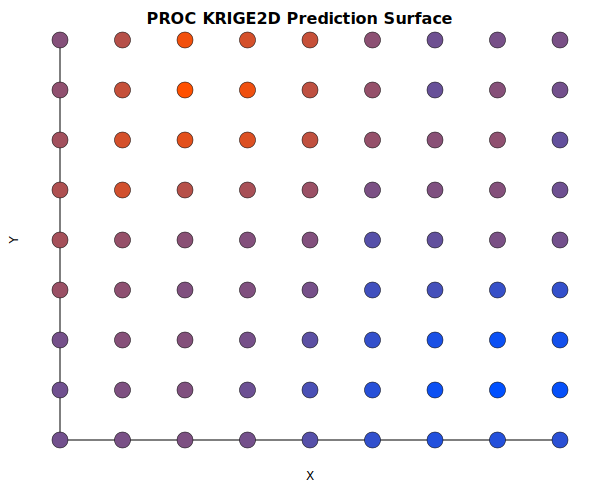

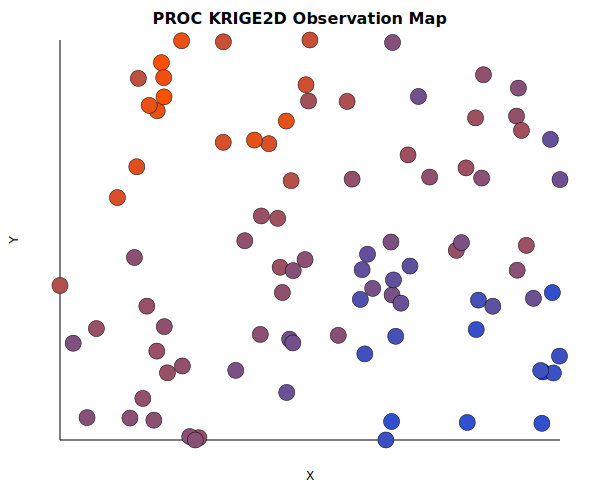

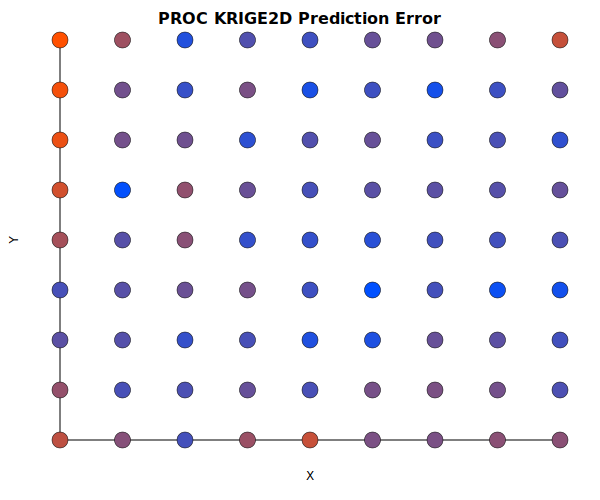

In [3]:
proc krige2d data=ed_sites outest=krige_sph outnbhd=nbhd_sph
      plots(only)=(observations prediction(fill=pred line=se));
   title 'Ordinary Kriging of ED Wait Times - Spherical Model';
   coordinates xc=east yc=north;
   predict var=wait_min radius=20 minpoints=10 maxpoints=40;
   model form=spherical scale=120 range=18 nugget=14;
   grid x=0 to 50 by 6 y=0 to 50 by 6;
run;

## Step 4 - Inspect the kriged surface

The `OUTEST=` dataset holds one row per grid node with the predicted wait time (`estimate`) and its kriging standard error (`stderr`). We summarize the surface and flag the hottest predicted nodes - candidate zones where a new urgent-care site would relieve the most pressure.

The kriged surface mean (**35.55 minutes**) tracks the observed facility average (35.5) almost exactly, a sanity check that ordinary kriging is unbiased. Predictions range from **16.1** in the sparse southeast to **56.4** in the congested northwest; standard errors run from **5.1** where facilities are dense to **11.2** in thinly sampled corners. The six hottest nodes all sit in the NW quadrant - their grid coordinates span x = 6-18 and y = 36-48 - squarely on the downtown surge built into the data.

In [4]:
proc means data=krige_sph n mean min max maxdec=2;
   title 'Kriged Surface Summary (Predicted Wait Minutes and Std Error)';
   var estimate stderr;
run;

proc sort data=krige_sph out=hot_nodes;
   by descending estimate;
run;

proc print data=hot_nodes(obs=6) noobs;
   title 'Six Grid Nodes with the Highest Predicted ED Wait Times';
   var x y estimate stderr;
run;

                             Kriged Surface Summary (Predicted Wait Minutes and Std Error)                              

                                                  The MEANS Procedure

 Variable        N        Mean     Minimum     Maximum
 -----------------------------------------------------
 ESTIMATE       81       35.55       16.07       56.38
 STDERR         81        7.38        5.06       11.20
 -----------------------------------------------------

                                Six Grid Nodes with the Highest Predicted ED Wait Times                                 

 X   Y       ESTIMATE        STDERR
12  42  56.3838526129  6.3860887297
12  48   54.379464215   5.876759721
18  42    53.81777091  8.0028060667
12  36  51.9499223116  7.7283024845
18  36  50.7825137373  6.1546512678
 6  36  49.6363903072  7.8641112964

... 75 more observations (showing 6 of 81)



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Step 5 - Predict at specific candidate sites

Network planning has three proposed urgent-care locations. We krige directly at each point by supplying it as a single-node grid (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), giving planners the predicted wait time and its kriging standard error at the exact coordinate.

The candidate near the downtown core, **(14, 37)**, returns the highest predicted wait - **52.2 +/- 7.3 minutes** - confirming it would absorb demand from the busiest EDs. The southeast candidate **(32, 12)** sits in the quiet suburban corner at **22.0 +/- 6.2**, and the northeast candidate **(42, 44)** lands mid-range at **36.4 +/- 5.9**. On predicted wait alone, the downtown candidate is the strongest evidence-based siting case.

In [5]:
proc krige2d data=ed_sites outest=cand_dt plots=none;
   title 'Candidate A - Downtown Core (14, 37)';
   coordinates xc=east yc=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   model form=spherical scale=120 range=18 nugget=14;
   grid x=14 to 14 by 1 y=37 to 37 by 1;
run;

proc krige2d data=ed_sites outest=cand_se plots=none;
   title 'Candidate B - Suburban Southeast (32, 12)';
   coordinates xc=east yc=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   model form=spherical scale=120 range=18 nugget=14;
   grid x=32 to 32 by 1 y=12 to 12 by 1;
run;

proc krige2d data=ed_sites outest=cand_ne plots=none;
   title 'Candidate C - Northeast Edge (42, 44)';
   coordinates xc=east yc=north;
   predict var=wait_min radius=20 minpoints=8 maxpoints=40;
   model form=spherical scale=120 range=18 nugget=14;
   grid x=42 to 42 by 1 y=44 to 44 by 1;
run;

data candidates;
   set cand_dt cand_se cand_ne;
run;

proc print data=candidates noobs;
   title 'Predicted ED Wait Times at Three Candidate Urgent-Care Sites';
   var x y estimate stderr;
run;

                                Six Grid Nodes with the Highest Predicted ED Wait Times                                 

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                                Six Grid Nodes with the Highest Predicted ED Wait Times                                 

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32

NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.17.1
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.17.1
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.17.1
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Interpreting the results

- **The kriged surface reproduces the catchment's congestion structure.** The spherical ordinary-kriging model interpolates a smooth wait-time field whose grid-node mean (35.55 min) matches the observed facility average (35.5 min), with the highest predicted waits - up to 56.4 minutes - concentrated in the NW quadrant around the downtown surge near (15, 38) that we built into the synthetic data. That correspondence is a sanity check that the model is behaving.
- **Standard errors localize confidence.** The kriging standard error ranges from 5.1 minutes where facilities are dense to 11.2 in the thinly sampled catchment corners. Planners should treat predictions in high-`stderr` zones cautiously; those are also the areas where adding a facility would most improve both future coverage and future measurement.
- **Point predictions support siting decisions.** Kriging the three candidate locations directly turns the surface into an actionable table. The downtown candidate (14, 37) shows the highest predicted wait (52.2 min) with a moderate standard error (7.3), making it the strongest evidence-based case for a new urgent-care site to offload the busiest ED; the suburban-southeast candidate (32, 12) sits in a low-demand corner (22.0 min) and the northeast-edge candidate (42, 44) is mid-range (36.4 min).

In practice the semivariogram parameters (`SCALE`, `RANGE`, `NUGGET`) would be estimated empirically with PROC VARIOGRAM and then passed to KRIGE2D - either as explicit values as shown here, or automatically via `RESTORE` from a VARIOGRAM item store.